In [3]:
import pandas as pd
import numpy as np
!pip install duckdb
import duckdb

df_customers_data=pd.read_csv(r'C:\Users\erika\OneDrive\Área de Trabalho\CIENCIA DE DADOS\Trabalho Final\customers_data.csv')
df_drivers_data=pd.read_csv(r'C:\Users\erika\OneDrive\Área de Trabalho\CIENCIA DE DADOS\Trabalho Final\drivers_data.csv')
df_missing_items_data= pd.read_csv(r'C:\Users\erika\OneDrive\Área de Trabalho\CIENCIA DE DADOS\Trabalho Final\missing_items_data.csv')
df_orders=pd.read_csv(r'C:\Users\erika\OneDrive\Área de Trabalho\CIENCIA DE DADOS\Trabalho Final\orders.csv')
df_products_data= pd.read_csv(r'C:\Users\erika\OneDrive\Área de Trabalho\CIENCIA DE DADOS\Trabalho Final\products_data.csv')


df_products_data


,produc_id,product_name,category,price
0,PWPX0982761090982,Kellogg's Frosties,Supermarket,$12.53
1,PWPX0982761090983,Uncured Bacon,Supermarket,$4.67
2,PWPX0982761090984,Whole Milk,Supermarket,$9.95
3,PWPX0982761090985,Organic Bananas,Supermarket,$3.94
4,PWPX0982761090986,Sourdough Bread,Supermarket,$19.77
...,...,...,...,...
309,PWPX0982761091291,Crest Toothpaste,Beverages,$8.72
310,PWPX0982761091292,Sensodyne Toothpaste,Household,$13.63
311,PWPX0982761091293,Listerine Mouthwash,Pantry,$12.74
312,PWPX0982761091294,Scope Mouthwash,Frozen,$5.94


In [4]:
# Entender o tamanho dos dados (linhas e colunas)

print("Orders:", df_orders.shape)
print("Drivers:", df_drivers_data.shape)
print("Customers:", df_customers_data.shape)
print("Products:", df_products_data.shape)
print("Missing Items:", df_missing_items_data.shape)

Orders: (10000, 9)
Drivers: (1247, 4)
Customers: (1239, 3)
Products: (314, 4)
Missing Items: (1501, 4)


In [5]:
# Ver estrutura das tabela ORDERS

df_orders.info()
df_orders.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   date             10000 non-null  object
 1   order_id         10000 non-null  object
 2   order_amount     10000 non-null  object
 3   region           10000 non-null  object
 4   items_delivered  10000 non-null  int64 
 5   items_missing    10000 non-null  int64 
 6   delivery_hour    10000 non-null  object
 7   driver_id        10000 non-null  object
 8   customer_id      10000 non-null  object
dtypes: int64(2), object(7)
memory usage: 703.3+ KB


,date,order_id,order_amount,region,items_delivered,items_missing,delivery_hour,driver_id,customer_id
0,2023-01-01,c9da15aa-be24-4871-92a3-dfa7746fff69,"$1,095.54",Winter Park,10,1,8:37:28,WDID10627,WCID5031
1,2023-01-01,ccacc183-09f8-4fd5-af35-009d18656326,$659.11,Altamonte Springs,11,1,9:31:17,WDID10533,WCID5794
2,2023-01-01,f4e1d30b-c3d1-413f-99b8-93c0b46d68bf,$251.45,Winter Park,18,1,10:43:49,WDID10559,WCID5599
3,2023-01-01,993d31f4-9358-41f0-a371-0021e55cef5d,$598.83,Altamonte Springs,12,1,9:48:33,WDID10622,WCID5005
4,2023-01-01,3e0a8f1b-3cd6-4d64-90e3-6b38dc368925,$27.18,Clermont,3,1,10:09:49,WDID10654,WCID5114


In [6]:
# Arrumamos colunas da data, order_amount (tiramos simbolo de moeda e colcoamos virgula no lugar do ponto) e delivery hour

# Data: colocamos errors=coerce para que se tem um erro como nulo ou outro apareça NA ou algo assim
df_orders["date"] = pd.to_datetime(df_orders["date"], errors="coerce")

# Order_Amount: Convertemos o string em string e retiramos o simbolo de moeda e tb retiramos o separador de milhares como virgula. 
# Depois que esta certo o numero, transformamos ele par afloat ou seja para decimal.

df_orders["order_amount"] = (
    df_orders["order_amount"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)  # só se tiver separador de milhar
    .str.strip()
)

df_orders["order_amount"] = pd.to_numeric(df_orders["order_amount"], errors="coerce")


# Delilvery_Hour: passamos ele para datetima ou hora numérica

df_orders["delivery_hour"] = pd.to_datetime(
    df_orders["delivery_hour"],
    format="%H:%M:%S",
    errors="coerce"
)

df_orders["delivery_hour_only"] = df_orders["delivery_hour"].dt.hour




df_orders.info()
df_orders

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                10000 non-null  datetime64[ns]
 1   order_id            10000 non-null  object        
 2   order_amount        10000 non-null  float64       
 3   region              10000 non-null  object        
 4   items_delivered     10000 non-null  int64         
 5   items_missing       10000 non-null  int64         
 6   delivery_hour       10000 non-null  datetime64[ns]
 7   driver_id           10000 non-null  object        
 8   customer_id         10000 non-null  object        
 9   delivery_hour_only  10000 non-null  int32         
dtypes: datetime64[ns](2), float64(1), int32(1), int64(2), object(4)
memory usage: 742.3+ KB


,date,order_id,order_amount,region,items_delivered,items_missing,delivery_hour,driver_id,customer_id,delivery_hour_only
0,2023-01-01,c9da15aa-be24-4871-92a3-dfa7746fff69,1095.54,Winter Park,10,1,1900-01-01 08:37:28,WDID10627,WCID5031,8
1,2023-01-01,ccacc183-09f8-4fd5-af35-009d18656326,659.11,Altamonte Springs,11,1,1900-01-01 09:31:17,WDID10533,WCID5794,9
2,2023-01-01,f4e1d30b-c3d1-413f-99b8-93c0b46d68bf,251.45,Winter Park,18,1,1900-01-01 10:43:49,WDID10559,WCID5599,10
3,2023-01-01,993d31f4-9358-41f0-a371-0021e55cef5d,598.83,Altamonte Springs,12,1,1900-01-01 09:48:33,WDID10622,WCID5005,9
4,2023-01-01,3e0a8f1b-3cd6-4d64-90e3-6b38dc368925,27.18,Clermont,3,1,1900-01-01 10:09:49,WDID10654,WCID5114,10
...,...,...,...,...,...,...,...,...,...,...
9995,2023-12-31,29788123-2b83-48ac-964f-9d308881af80,330.64,Orlando,12,0,1900-01-01 18:30:45,WDID10616,WCID5916,18
9996,2023-12-31,0c812aa6-2c8d-458f-949a-0571f6391a28,349.04,Sanford,18,0,1900-01-01 03:10:40,WDID10738,WCID5967,3
9997,2023-12-31,de5a00dd-24cb-4bfa-bfe9-ad94db89d783,26.73,Altamonte Springs,13,0,1900-01-01 22:13:24,WDID10775,WCID5564,22
9998,2023-12-31,5b9e992f-abaf-499b-9cf8-60f59dc10a8b,281.44,Orlando,12,0,1900-01-01 03:20:54,WDID11002,WCID6020,3


In [7]:
# Vamos criar algumas métricas

df_orders["items_total"] = df_orders["items_delivered"] + df_orders["items_missing"]

df_orders["missing_rate"] = df_orders["items_missing"] / df_orders["items_total"]

df_orders["has_missing"] = (df_orders["items_missing"] > 0).astype(int)

df_orders.head()

,date,order_id,order_amount,region,items_delivered,items_missing,delivery_hour,driver_id,customer_id,delivery_hour_only,items_total,missing_rate,has_missing
0,2023-01-01,c9da15aa-be24-4871-92a3-dfa7746fff69,1095.54,Winter Park,10,1,1900-01-01 08:37:28,WDID10627,WCID5031,8,11,0.090909,1
1,2023-01-01,ccacc183-09f8-4fd5-af35-009d18656326,659.11,Altamonte Springs,11,1,1900-01-01 09:31:17,WDID10533,WCID5794,9,12,0.083333,1
2,2023-01-01,f4e1d30b-c3d1-413f-99b8-93c0b46d68bf,251.45,Winter Park,18,1,1900-01-01 10:43:49,WDID10559,WCID5599,10,19,0.052632,1
3,2023-01-01,993d31f4-9358-41f0-a371-0021e55cef5d,598.83,Altamonte Springs,12,1,1900-01-01 09:48:33,WDID10622,WCID5005,9,13,0.076923,1
4,2023-01-01,3e0a8f1b-3cd6-4d64-90e3-6b38dc368925,27.18,Clermont,3,1,1900-01-01 10:09:49,WDID10654,WCID5114,10,4,0.250000,1


In [8]:
# Ver estrutura das tabela CUSTOMERS_DATA

df_customers_data.info()
df_customers_data.head()

# Parece estar todo ok , só poderiamos verificar a coluna de idade para garantir que não tenha valores irreais.

df_customers_data["customer_age"].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1239 entries, 0 to 1238
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customer_id    1239 non-null   object
 1   customer_name  1239 non-null   object
 2   customer_age   1239 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 29.2+ KB


count    1239.000000
mean       54.421308
std        20.911501
min        18.000000
25%        36.000000
50%        55.000000
75%        73.000000
max        90.000000
Name: customer_age, dtype: float64

In [15]:
# Ver estrutura das tabela DRIVERS_DATA

df_drivers_data.info()
df_drivers_data.head()

# Como vemos que aparece a idade 18 muitas vezes vamos olhar essa coluna

df_drivers_data["age"].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1247 entries, 0 to 1246
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   driver_id    1247 non-null   object
 1   driver_name  1247 non-null   object
 2   age          1247 non-null   int64 
 3   Trips        1247 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 39.1+ KB


count    1247.000000
mean       34.170810
std        15.441928
min        18.000000
25%        20.000000
50%        30.000000
75%        48.000000
max        65.000000
Name: age, dtype: float64

In [17]:
# Ver estrutura das tabela PRODUCTS_DATA

df_products_data.info()
df_products_data.head()


df_products_data["price"] = (df_products_data["price"]
                             .astype(str)
                             .str.replace("$", "", regex=False)  #regex false significa que é para interpretar apenas esse simbolo, nenhum parecido
                             .str.replace(",", "", regex=False)
                             .str.strip())

df_products_data["price"] = pd.to_numeric(df_products_data["price"], errors="coerce")

df_products_data.info()
df_products_data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 314 entries, 0 to 313
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   produc_id     314 non-null    object
 1   product_name  314 non-null    object
 2   category      314 non-null    object
 3   price         314 non-null    object
dtypes: object(4)
memory usage: 9.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 314 entries, 0 to 313
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   produc_id     314 non-null    object 
 1   product_name  314 non-null    object 
 2   category      314 non-null    object 
 3   price         314 non-null    float64
dtypes: float64(1), object(3)
memory usage: 9.9+ KB


,produc_id,product_name,category,price
0,PWPX0982761090982,Kellogg's Frosties,Supermarket,12.53
1,PWPX0982761090983,Uncured Bacon,Supermarket,4.67
2,PWPX0982761090984,Whole Milk,Supermarket,9.95
3,PWPX0982761090985,Organic Bananas,Supermarket,3.94
4,PWPX0982761090986,Sourdough Bread,Supermarket,19.77
...,...,...,...,...
309,PWPX0982761091291,Crest Toothpaste,Beverages,8.72
310,PWPX0982761091292,Sensodyne Toothpaste,Household,13.63
311,PWPX0982761091293,Listerine Mouthwash,Pantry,12.74
312,PWPX0982761091294,Scope Mouthwash,Frozen,5.94


In [19]:
# Ver estrutura das tabela MISSING_DATA

df_missing_items_data.info()
df_missing_items_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1501 entries, 0 to 1500
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   order_id      1501 non-null   object
 1   product_id_1  1501 non-null   object
 2   product_id_2  143 non-null    object
 3   product_id_3  18 non-null     object
dtypes: object(4)
memory usage: 47.0+ KB


,order_id,product_id_1,product_id_2,product_id_3
0,c7a343f7-3f1d-497c-8004-b9ede2d48fb1,PWPX0982761090982,PWPX0982761090982,PWPX0982761090982
1,20698293-8399-4fda-af1e-b61a9ebb8a0a,PWPX0982761090983,PWPX0982761090983,PWPX0982761090983
2,d7f690a0-c1c2-4b36-b05f-2b7e641ea1ac,PWPX0982761090984,PWPX0982761090984,PWPX0982761090984
3,d5cea1eb-7016-451b-9426-51973f4d6e14,PWPX0982761090985,PWPX0982761090985,PWPX0982761090985
4,2f7cbda8-793a-4a1d-bb66-3a514bee5dc4,PWPX0982761090986,PWPX0982761090986,PWPX0982761090986


In [21]:
# Vamos a arrumar a coluna de CATEGORY de PRODUCTS_DATA

import re

df_products_data = df_products_data.copy()

# 1) Normalização básica (evita erro por espaço/caixa)
df_products_data["product_name_clean"] = (
    df_products_data["product_name"]
    .astype(str)
    .str.strip()
)

# 2) Cria categoria corrigida (começa igual a original)
df_products_data["category_corrected"] = (
    df_products_data["category"]
    .astype(str)
    .str.strip()
)

# 3) Regras por categoria (você pode ajustar as listas)
# Obs: usei exemplos diretamente dos seus prints: detergents/paper towels no "Produce", etc.
RULES = [
    # --- Alta prioridade: Eletrônicos ---
    ("Electronics", [
        r"\b(tv|oled|qled|laptop|macbook|iphone|ipad|android|phone|camera|lumix)\b",
        r"\b(headphone|earbud|earbuds|speaker|chromecast|printer|router)\b",
        r"\b(xbox|playstation|nintendo|switch|gopro|beats|logitech|samsung|bose|sony|canon|amazon echo|surface)\b",
        r"\b(gpu|geforce|rtx)\b",
    ]),

    # --- Limpeza / Household (papel, limpeza, lavanderia) ---
    # (mantive como "Household" porque já existe no seu dataset)
    ("Household", [
        r"\b(paper towel|paper towels|toilet paper|tissue|napkin|wipes)\b",
        r"\b(bleach|disinfect|disinfecting|lysol|clorox|cleaner|stain remover)\b",
        r"\b(detergent|laundry|fabric softener|dishwasher|pods|cascade|gain|downy|swiffer)\b",
        r"\b(trash bags|ziploc|aluminum foil|foil|bounty|charmin)\b",
        r"\b(air freshener|febreze)\b",
    ]),

    # --- Personal Care / Higiene ---
    ("Personal Care", [
        r"\b(toothpaste|mouthwash|toothbrush|soap|shampoo|conditioner|deodorant)\b",
        r"\b(pads|tampons|always|tampax|playtex)\b",
        r"\b(razor|shaving|lotion)\b",
        r"\b(batteries)\b",  # pilhas normalmente não é personal care, mas aparece errado; se preferir, mova para Household
    ]),

    # --- Bebidas ---
    ("Beverages", [
        r"\b(water|sparkling water|seltzer|tea|iced tea|coffee|frappuccino)\b",
        r"\b(coke|coca\-cola|pepsi|sprite|dr pepper|mountain dew|red bull)\b",
        r"\b(juice|lemonade|gatorade|smartwater|poland spring|evian|dasani)\b",
    ]),

    # --- Dairy (laticínios) ---
    ("Dairy", [
        r"\b(milk|almond milk|yogurt|cream cheese|cheese|whip|cool whip)\b",
    ]),

    # --- Frozen / Congelados ---
    ("Frozen", [
        r"\b(frozen|ice cream|ben & jerry|eggo|waffles)\b",
    ]),

    # --- Produce (hortifruti) ---
    # (dataset pode ter pouco "produce" de verdade; deixo regra bem restrita)
    ("Produce", [
        r"\b(apple|banana|strawberry|avocado|orange|lettuce|spinach|tomato|potato|onion|grapes)\b",
    ]),

    # --- Bakery / Padaria ---
    ("Bakery", [
        r"\b(bread|bagel|donut|cake mix|raisins|oats)\b",
        r"\b(lean cuisine)\b",  # se preferir, isso não é bakery; ajuste conforme seu entendimento
    ]),

    # --- Pantry / Mercearia ---
    ("Pantry", [
        r"\b(cereal|granola|oats|rice|pasta|mac|crackers|pretzels|chips|cookies)\b",
        r"\b(ketchup|mustard|mayo|mayonnaise|sauce|olive oil)\b",
        r"\b(chocolate|hershey|kit kat|m&m|candy)\b",
    ]),

    # --- Snacks (mantém para itens bem típicos) ---
    ("Snacks", [
        r"\b(oreo|cheetos|tostitos|goldfish|pringle|pringles|velveeta|snickers)\b",
        r"\b(pop\-tarts|chips)\b",
    ]),
]

def apply_rules_category(df: pd.DataFrame, rules=RULES, col_name="product_name_clean"):
    name_series = df[col_name].fillna("").astype(str)

    # aplica em ordem: se bater regra, sobrescreve category_corrected
    for cat, patterns in rules:
        pattern = re.compile("|".join(patterns), flags=re.IGNORECASE)
        mask = name_series.str.contains(pattern)
        df.loc[mask, "category_corrected"] = cat

    return df

df_products_data = apply_rules_category(df_products_data)

# 4) Relatório de checagem: quantos mudaram?
df_products_data["category_changed"] = (df_products_data["category_corrected"] != df_products_data["category"])

print("Total produtos:", len(df_products_data))
print("Categorias corrigidas (mudaram):", int(df_products_data["category_changed"].sum()))
print("\nTop mudanças (original -> corrigida):")
print(
    df_products_data.loc[df_products_data["category_changed"], ["category", "category_corrected"]]
    .value_counts()
    .head(15)
)

# 5) Amostra dos itens corrigidos (para você validar)
display(
    df_products_data.loc[df_products_data["category_changed"], 
                         ["produc_id","product_name","category","category_corrected","price"]]
    .head(30)
)

Total produtos: 314
Categorias corrigidas (mudaram): 161

Top mudanças (original -> corrigida):
category     category_corrected
Supermarket  Frozen                15
             Pantry                14
             Produce                9
Household    Beverages              8
Supermarket  Dairy                  8
Snacks       Pantry                 6
Supermarket  Bakery                 5
Bakery       Pantry                 5
Dairy        Beverages              5
Electronics  Produce                4
Pantry       Personal Care          4
Produce      Beverages              4
             Household              4
             Pantry                 4
Bakery       Beverages              4
Name: count, dtype: int64


C:\Users\erika\AppData\Local\Temp\ipykernel_6884\3175203476.py:99: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = name_series.str.contains(pattern)
C:\Users\erika\AppData\Local\Temp\ipykernel_6884\3175203476.py:99: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = name_series.str.contains(pattern)
C:\Users\erika\AppData\Local\Temp\ipykernel_6884\3175203476.py:99: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = name_series.str.contains(pattern)
C:\Users\erika\AppData\Local\Temp\ipykernel_6884\3175203476.py:99: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = name_series.str.contains(pattern)
C:\Users\erika\AppData\Local

,produc_id,product_name,category,category_corrected,price
2,PWPX0982761090984,Whole Milk,Supermarket,Dairy,9.95
4,PWPX0982761090986,Sourdough Bread,Supermarket,Bakery,19.77
5,PWPX0982761090987,Cheddar Cheese,Supermarket,Dairy,12.47
6,PWPX0982761090988,Greek Yogurt,Supermarket,Dairy,18.01
7,PWPX0982761090989,Tomato Soup,Supermarket,Produce,7.82
8,PWPX0982761090990,Frozen Peas,Supermarket,Frozen,10.10
11,PWPX0982761090993,Ground Coffee,Supermarket,Beverages,13.28
14,PWPX0982761090996,Oat Milk,Supermarket,Dairy,19.58
17,PWPX0982761090999,Brown Rice,Supermarket,Pantry,17.11
18,PWPX0982761091000,Bagged Spinach,Supermarket,Produce,17.28


In [27]:
df_products_data

,produc_id,product_name,category,price,product_name_clean,category_corrected,category_changed
0,PWPX0982761090982,Kellogg's Frosties,Supermarket,12.53,Kellogg's Frosties,Supermarket,False
1,PWPX0982761090983,Uncured Bacon,Supermarket,4.67,Uncured Bacon,Supermarket,False
2,PWPX0982761090984,Whole Milk,Supermarket,9.95,Whole Milk,Dairy,True
3,PWPX0982761090985,Organic Bananas,Supermarket,3.94,Organic Bananas,Supermarket,False
4,PWPX0982761090986,Sourdough Bread,Supermarket,19.77,Sourdough Bread,Bakery,True
...,...,...,...,...,...,...,...
309,PWPX0982761091291,Crest Toothpaste,Beverages,8.72,Crest Toothpaste,Personal Care,True
310,PWPX0982761091292,Sensodyne Toothpaste,Household,13.63,Sensodyne Toothpaste,Personal Care,True
311,PWPX0982761091293,Listerine Mouthwash,Pantry,12.74,Listerine Mouthwash,Personal Care,True
312,PWPX0982761091294,Scope Mouthwash,Frozen,5.94,Scope Mouthwash,Personal Care,True


In [23]:
df_drivers_data.head()
df_orders.head()

# O PROBLEMA ESTÁ OCNCENTRADO EM ALGUNS MOTORISTAS?

driver_analysis = (
    df_orders.groupby("driver_id", as_index=False)
    .agg(
        total_orders=("order_id", "count"),
        total_missing_orders=("has_missing", "sum"),
        problem_rate=("has_missing", "mean"),
        avg_items_missing=("items_missing", "mean"),
        avg_order_value=("order_amount", "mean")
    )
)

driver_analysis = driver_analysis.sort_values(
    ["problem_rate", "total_missing_orders"],
    ascending=False
)

driver_analysis


# vamos verificar a taxa media geral e analisar a taxa de pedidos com problema.

overall_rate = df_orders["has_missing"].mean()
print("Taxa média geral:", round(overall_rate*100, 2), "%")

driver_analysis
driver_analysis["problem_rate"].describe()

# Mediana=0 significa qe mais da metade dos motoristas nao tiveram nenhum pedido com item faltante. 
# Maximo = 36% vs média geral 15% é mais do dobro.
# Desvio Padrão = 15% indica grande dispersão. 
# Existe grande evidencia de concentração do porblema em um subconjunto de motoristas porque muitos tem taxa 0%, 
# alguns ten taxa muito alta e existe alta dispersão

# Vamos ver quais motoristas têm taxa de problema acima de 30%

high_risk_drivers = driver_analysis[driver_analysis["problem_rate"] > 0.30]

print("Quantidade de motoristas acima de 30%:", high_risk_drivers.shape[0])

high_risk_drivers

# Vamos ver a distribuição real de pedidos por motorista - Pirmeir contamos quantos pedidos cada motorista fez e depois analisamos estatisticamente
# essa distribuição (como está distribuido o numero de pedidos por motorista? tem alguns motoristas poucos pedidos? há grande variação no volume 
# de entregas?)

df_orders["driver_id"].value_counts().describe()

# vemos que  a maioria dos motoristas fez entre 6 e 11 pedidos. Não existe motorista com 50 ou 100 entregas. Todos estão em uma faixam muito parecida.
# O dataset está balanceado. O volume de pedidos não parece ser um fator explicativo.
# A concentração de taxa elevada em alguns motoristas não pode ser explicada por volume de entregas pois a distribuição de pedidos por motorista é
# homogênea.


Taxa média geral: 15.02 %
Quantidade de motoristas acima de 30%: 227


count    1247.000000
mean        8.019246
std         2.099747
min         6.000000
25%         6.000000
50%         7.000000
75%        11.000000
max        11.000000
Name: count, dtype: float64

In [31]:
# Calculamos métricas por região (O porblema está concentrado por região?)

# 1.Calcular métricas pro região

region_analysis = (
    df_orders
    .groupby("region", as_index=False)
    .agg(
        total_orders=("order_id", "count"),
        problem_orders=("has_missing", "sum"),
        problem_rate=("has_missing", "mean"),
        avg_items_missing=("items_missing", "mean"),
        avg_order_value=("order_amount", "mean")
    )
    .sort_values("problem_rate", ascending=False)
)

region_analysis

,region,total_orders,problem_orders,problem_rate,avg_items_missing,avg_order_value
0,Altamonte Springs,1426,231,0.161992,0.177419,286.509222
2,Clermont,1384,219,0.158237,0.175578,282.277868
1,Apopka,1422,218,0.153305,0.175105,285.457377
4,Orlando,1401,212,0.151320,0.166310,282.686759
6,Winter Park,1485,215,0.144781,0.158249,282.525508
3,Kissimmee,1421,204,0.143561,0.154117,275.906108
5,Sanford,1461,203,0.138946,0.154004,287.618179


In [166]:
region_analysis.sort_values(by="problem_rate", ascending=False)

,region,total_orders,problem_orders,problem_rate,avg_items_missing,avg_order_value
0,Altamonte Springs,1426,231,0.161992,0.177419,286.509222
2,Clermont,1384,219,0.158237,0.175578,282.277868
1,Apopka,1422,218,0.153305,0.175105,285.457377
4,Orlando,1401,212,0.151320,0.166310,282.686759
6,Winter Park,1485,215,0.144781,0.158249,282.525508
3,Kissimmee,1421,204,0.143561,0.154117,275.906108
5,Sanford,1461,203,0.138946,0.154004,287.618179


In [172]:
# comparamos com a média geral. Alguma região tem 25%? Alguma tem 5%? oue stão todas perto de 15%?
# Não há evidência forte de que o porblema esteja concentrado em uma região especifica, taxas são muiro parecidas


In [33]:
# HORARIOS DE ENTREGA:
# Entregas noturnas tem mais problema? existem horarios espcificos com mais concorrência? os motoristas aproveitam
# horarios com menor supervisao?

hour_analysis = (
    df_orders
    .groupby("delivery_hour_only", as_index=False)
    .agg(
        total_orders=("order_id", "count"),
        problem_orders=("has_missing", "sum"),
        problem_rate=("has_missing", "mean")
    )
    .sort_values("delivery_hour_only")
)

hour_analysis

,delivery_hour_only,total_orders,problem_orders,problem_rate
0,0,412,56,0.135922
1,1,377,50,0.132626
2,2,432,68,0.157407
3,3,477,68,0.142558
4,4,414,67,0.161836
5,5,445,66,0.148315
6,6,387,70,0.180879
7,7,439,78,0.177677
8,8,422,65,0.154028
9,9,401,55,0.137157


In [178]:
# Vemos que existe indicio de padrão temporal. Pico as 22 h , taxas elevadas no início da manhã (6h-7h), horário 16h tem a menor taxa

In [180]:
# O volume por horário é semelhante? todos os horários tem ente 380 e 480 pedidos
# HORARIO sem pode ser um fator explicativo

In [35]:
# Cruzamos Motorista x Horário

driver_hour_analysis = (
    df_orders
    .groupby(["driver_id", "delivery_hour_only"], as_index=False)
    .agg(
        total_orders=("order_id", "count"),
        problem_rate=("has_missing", "mean")
    )
)

driver_hour_analysis.sort_values("problem_rate", ascending=False)

,driver_id,delivery_hour_only,total_orders,problem_rate
6507,WDID10738,14,1,1.0
5533,WDID10626,19,1,1.0
1366,WDID10075,19,1,1.0
5538,WDID10627,8,1,1.0
1362,WDID10075,12,1,1.0
...,...,...,...,...
2944,WDID10302,21,1,0.0
2943,WDID10302,18,1,0.0
2942,WDID10302,16,1,0.0
2941,WDID10302,13,1,0.0


In [37]:
driver_hour_analysis_filtered = driver_hour_analysis[
    driver_hour_analysis["total_orders"] >= 5
]

driver_hour_analysis_filtered.sort_values("problem_rate", ascending=False).head(10)

,driver_id,delivery_hour_only,total_orders,problem_rate


In [200]:
# Por horário temos uma variação moderada mas nao extrema e para analisar motorista x horário temos uma amostra pequena.

In [39]:
# MISSING ITEMS DATA. Vamos a transformar essa tabeal que tem muitas colunas para uma tabela long verticalizada)
# "melt()", transforma colunas em linhas, "dropna()" remove céllular vazias. Agora cada linha representa 1 item faltante.
# Cruza as tabelas de products com missing_items.
# Analizamos as categorias


missing_long = (
    df_missing_items_data
    .melt(
        id_vars="order_id",
        value_vars=["product_id_1", "product_id_2", "product_id_3"],
        value_name="product_id"
    )
    .dropna(subset=["product_id"])
    [["order_id", "product_id"]]
)

missing_long.head()


missing_products = missing_long.merge(
    df_products_data,
    left_on="product_id",
    right_on="produc_id",
    how="left"
)

missing_products.head()


category_analysis = (
    missing_products
    .groupby("category", as_index=False)
    .agg(
        total_missing_items=("product_id", "count"),
        avg_price=("price", "mean")
    )
    .sort_values("total_missing_items", ascending=False)
)

category_analysis

,category,total_missing_items,avg_price
1,Supermarket,1393,11.467344
0,Electronics,269,495.905576


In [41]:
# Continuamos analisando PRODUTOS /CATEGORIAS (Certos produtos ou categorias tem mais oocorrência de falta?)

# supermarket tem muito mais pordutos no catálogo
# supermarket tem muito mais volume
# entaço naturalmente terá mais ocorreências absolutas

# Agora precisamos calcular a taxa relativa (em todos os itens vendidos de cada cateoria, qual proporção está faltando?)

# Primeiro precisamos saber todos os produtos vendidos por categoria
# Para isso precisamos relacionar orders com products (isso depende da estrutura do seu dataset)

cat_col = "category_corrected" if "category_corrected" in missing_products.columns else "category"

category_impact = (
    missing_products
    .groupby(cat_col, as_index=False)
    .agg(
        total_missing_items=("product_id", "count"),
        total_loss_estimated=("price", "sum"),
        avg_price=("price", "mean")
    )
    .sort_values("total_loss_estimated", ascending=False)
)

category_impact

,category_corrected,total_missing_items,total_loss_estimated,avg_price
3,Electronics,236,122252.71,518.019958
6,Produce,138,12383.32,89.734203
8,Supermarket,736,8389.56,11.398859
4,Frozen,171,1702.66,9.957076
5,Pantry,163,1651.16,10.129816
2,Dairy,104,1586.78,15.257500
0,Bakery,62,853.22,13.761613
7,Snacks,25,279.12,11.164800
1,Beverages,27,274.08,10.151111


In [43]:
top_missing_products = (
    missing_products
    .groupby(["product_id", "product_name"], as_index=False)
    .agg(
        missing_count=("order_id", "count"),
        avg_price=("price", "mean")
    )
    .sort_values("missing_count", ascending=False)
    .head(15)
)

top_missing_products

,product_id,product_name,missing_count,avg_price
15,PWPX0982761090997,Chicken Breast,19,5.93
11,PWPX0982761090993,Ground Coffee,19,13.28
5,PWPX0982761090987,Cheddar Cheese,18,12.47
96,PWPX0982761091078,Frozen Shrimp,17,4.71
1,PWPX0982761090983,Uncured Bacon,17,4.67
10,PWPX0982761090992,Canned Tuna,17,18.60
12,PWPX0982761090994,Peanut Butter,17,19.32
72,PWPX0982761091054,Turkey Burgers,16,8.48
31,PWPX0982761091013,Rice Cakes,16,6.56
81,PWPX0982761091063,Sweet Potatoes,15,11.02


In [218]:
# SUPERMARKET 
# Muito volume de faltas
# Preço médio baixo
#Impacto financeiro moderado

# ELECTRONICS
# muito menos ocorrencias
# mas impacto financeiro gigantesco
# sozinha representa a maior perda
# mesmo com poucas ocorrencias, Electronics gera muuito perjuizo

# INSIGHT FORTE PARA O MODELO: o porlema não é apenas frequência. O verdadeiro risco está em falta de itens de alto valor unitário. 
# Electronics é risco financeiro desproporcianal.


# VEMOS DUAS COISAS:
# 1- alto volume de pequenos itens (pode ser problema operacional)
# 2- baixo volume de itens caros (electronics). pode ser risco financeiro elevado.




In [45]:
# ELECTRONICS está distribuido entre varios motoristas? ou está concentrado em poucos?
# 1) Filtrar só eletrônicos
electronics_missing = missing_products[missing_products["category_corrected"] == "Electronics"].copy()

# 2) Trazer driver_id (e opcionalmente região/hora) a partir da tabela orders
electronics_missing = electronics_missing.merge(
    df_orders[["order_id", "driver_id", "region", "delivery_hour_only"]],
    on="order_id",
    how="left"
)

# 3) Agora sim: eletrônicos faltantes por motorista
electronics_by_driver = (
    electronics_missing
    .groupby("driver_id", as_index=False)
    .agg(
        total_missing_items=("product_id", "count"),
        total_loss_estimated=("price", "sum"),
        avg_price=("price", "mean")
    )
    .sort_values(["total_loss_estimated", "total_missing_items"], ascending=False)
)

electronics_by_driver.head(10)


,driver_id,total_missing_items,total_loss_estimated,avg_price
59,WDID10442,3,2010.24,670.080000
78,WDID10476,3,1872.08,624.026667
55,WDID10422,3,1859.97,619.990000
46,WDID10387,3,1721.19,573.730000
52,WDID10418,2,1663.45,831.725000
62,WDID10447,3,1661.03,553.676667
54,WDID10420,3,1619.41,539.803333
69,WDID10466,3,1563.52,521.173333
71,WDID10468,2,1460.99,730.495000
67,WDID10464,2,1441.60,720.800000


In [226]:
# o numero maximo de itens faltantes por motorista é 3
# nao existe ninguem com com 10,15 ou 20 eletronicos faltantes.
# está relativamente espalhado

# Não há evidencia forte de fraude direcionada em eletronicos por um pequeno grupo de motoristas.
# isso sugere: problema de controle operacional, falha de conferencia, possivel erro de separação


In [47]:
 # CRIAMOS UM SCORE DE RISCO POR PEDIDO: criar uma variavel de risco combinando: has_missing, missing rate, order_amount, categoria , 
# horario de maior risco

df_orders["high_value_order"] = df_orders["order_amount"] > df_orders["order_amount"].quantile(0.75)

df_orders["night_delivery"] = df_orders["delivery_hour_only"].isin([6,7,10,13,22]).astype(int)

df_orders["risk_score"] = (
    df_orders["has_missing"] * 2 +
    df_orders["missing_rate"] * 3 +
    df_orders["high_value_order"].astype(int) +
    df_orders["night_delivery"]
)

df_orders.sort_values("risk_score", ascending=False).head(10)

,date,order_id,order_amount,region,items_delivered,items_missing,delivery_hour,driver_id,customer_id,delivery_hour_only,items_total,missing_rate,has_missing,high_value_order,night_delivery,risk_score
3438,2023-05-08,21381fa4-08cd-47c2-9267-0a568846da42,1025.22,Apopka,1,1,1900-01-01 22:51:36,WDID09879,WCID5823,22,2,0.500000,1,True,1,5.5
3712,2023-05-18,be1004f2-973a-4750-9a47-6c6e0a747189,450.93,Kissimmee,1,1,1900-01-01 13:20:12,WDID10656,WCID5243,13,2,0.500000,1,True,1,5.5
4057,2023-06-01,074a77f9-bf9b-4f0a-8249-bb582b7d8add,445.95,Orlando,1,1,1900-01-01 10:18:33,WDID10645,WCID5611,10,2,0.500000,1,True,1,5.5
4060,2023-06-01,07210271-46e0-4f04-8ee9-7fbe1bcf6fbb,1166.12,Sanford,1,1,1900-01-01 07:16:53,WDID10519,WCID5033,7,2,0.500000,1,True,1,5.5
2804,2023-04-15,c308df27-e7bb-48b5-9ee5-31ca1515d259,459.74,Orlando,1,1,1900-01-01 07:15:05,WDID10518,WCID5470,7,2,0.500000,1,True,1,5.5
158,2023-01-07,eb96e4e9-9935-4387-8123-179dce564e5a,487.01,Kissimmee,3,2,1900-01-01 10:22:37,WDID10073,WCID5573,10,5,0.400000,1,True,1,5.2
2644,2023-04-09,1206f2bb-cc3f-4a5e-b07e-49c08c12298b,1045.57,Apopka,1,2,1900-01-01 00:57:31,WDID10224,WCID5227,0,3,0.666667,1,True,0,5.0
2803,2023-04-15,17e572a0-2beb-4da2-a898-d0207d994360,450.47,Winter Park,2,1,1900-01-01 06:46:52,WDID10562,WCID5328,6,3,0.333333,1,True,1,5.0
53,2023-01-03,462423f0-1d1e-48f0-9541-91f76e09e466,403.52,Kissimmee,2,1,1900-01-01 22:44:00,WDID10639,WCID5543,22,3,0.333333,1,True,1,5.0
2975,2023-04-21,091b676a-cafb-4a89-8f68-e145f50708e6,473.04,Sanford,4,2,1900-01-01 07:08:59,WDID10255,WCID6202,7,6,0.333333,1,True,1,5.0


In [49]:
# Agora precisamos valiidar esse score.
# Ver distribuição do score
# ver impacto financeiro dos pedidaos de alto risco
# cruzar com electronics


df_orders["risk_score"].value_counts().sort_index()

risk_score
0.000000    5204
1.000000    2917
2.000000     377
2.150000      40
2.157895      35
            ... 
4.600000       9
4.750000       7
5.000000      11
5.200000       1
5.500000       5
Name: count, Length: 81, dtype: int64

In [51]:
high_risk_orders = df_orders[df_orders["risk_score"] >= 5]

print("Quantidade de pedidos alto risco:", len(high_risk_orders))
print("Percentual do total:", len(high_risk_orders)/len(df_orders))

print("Valor total desses pedidos:", high_risk_orders["order_amount"].sum())

Quantidade de pedidos alto risco: 17
Percentual do total: 0.0017
Valor total desses pedidos: 9911.510000000002


In [53]:
high_risk_electronics = electronics_missing.merge(
    high_risk_orders[["order_id"]],
    on="order_id",
    how="inner"
)

high_risk_electronics["price"].sum()

2224.29

In [55]:
import numpy as np
import pandas as pd

# =========================
# 0) Garantias básicas
# =========================
# Certifique-se que essas colunas existem em df_orders:
# order_id, items_delivered, items_missing, delivery_hour_only, order_amount
# e que has_missing, items_total, missing_rate já foram criadas.

if "has_missing" not in df_orders.columns:
    df_orders["has_missing"] = (df_orders["items_missing"] > 0).astype(int)

if "items_total" not in df_orders.columns:
    df_orders["items_total"] = df_orders["items_delivered"] + df_orders["items_missing"]

if "missing_rate" not in df_orders.columns:
    df_orders["missing_rate"] = np.where(
        df_orders["items_total"] > 0,
        df_orders["items_missing"] / df_orders["items_total"],
        np.nan
    )

# Se order_amount ainda não estiver numérico:
df_orders["order_amount"] = (
    df_orders["order_amount"].astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
df_orders["order_amount"] = pd.to_numeric(df_orders["order_amount"], errors="coerce")


# =========================
# 1) Criar "loss_estimated" por pedido a partir de missing_products
# =========================
# missing_products precisa ter: order_id, product_id, price, category_corrected (ou category)

cat_col = "category_corrected" if "category_corrected" in missing_products.columns else "category"

order_loss = (
    missing_products
    .groupby("order_id", as_index=False)
    .agg(
        missing_items=("product_id", "count"),
        loss_estimated=("price", "sum"),
        max_missing_price=("price", "max"),
        electronics_missing_items=(cat_col, lambda s: (s == "Electronics").sum()),
        has_electronics_missing=(cat_col, lambda s: int((s == "Electronics").any()))
    )
)

# Junta no df_orders
df_orders_scored = df_orders.merge(order_loss, on="order_id", how="left")

# Preencher NA para pedidos sem missing (não aparecem em missing_products)
for c in ["missing_items", "loss_estimated", "max_missing_price", "electronics_missing_items", "has_electronics_missing"]:
    df_orders_scored[c] = df_orders_scored[c].fillna(0)

df_orders_scored["has_electronics_missing"] = df_orders_scored["has_electronics_missing"].astype(int)
df_orders_scored["electronics_missing_items"] = df_orders_scored["electronics_missing_items"].astype(int)


# =========================
# 2) Features adicionais (alto valor, horário de risco)
# =========================
# Você pode ajustar o quantile se quiser mais/menos sensível
df_orders_scored["high_value_order"] = (df_orders_scored["order_amount"] >= df_orders_scored["order_amount"].quantile(0.75)).astype(int)

# Horários que você viu com taxa mais alta (ajuste se quiser)
risk_hours = [6, 7, 10, 13, 22]
df_orders_scored["night_delivery"] = df_orders_scored["delivery_hour_only"].isin(risk_hours).astype(int)

# Flags focadas no "dano" (captar electronics)
df_orders_scored["high_loss_order"] = (df_orders_scored["loss_estimated"] >= df_orders_scored["loss_estimated"].quantile(0.90)).astype(int)
df_orders_scored["high_missing_item"] = (df_orders_scored["max_missing_price"] >= df_orders_scored["max_missing_price"].quantile(0.90)).astype(int)


# =========================
# 3) Risk Score V2 (mais sensível a Electronics)
# =========================
# Pesos sugeridos (pode ajustar):
# - has_missing: garante que só sobe score quando houve falta
# - missing_rate: severidade
# - loss_estimated: impacto financeiro do que faltou
# - has_electronics_missing / electronics_missing_items: prioriza eletrônicos
# - high_missing_item: pega item muito caro mesmo se o resto do pedido for “normal”
# - night_delivery: contextual (horário)

df_orders_scored["risk_score_v2"] = (
    df_orders_scored["has_missing"] * 2
    + df_orders_scored["missing_rate"].fillna(0) * 2
    + df_orders_scored["night_delivery"] * 1
    + df_orders_scored["high_value_order"] * 1
    + df_orders_scored["high_loss_order"] * 3
    + df_orders_scored["high_missing_item"] * 2
    + df_orders_scored["has_electronics_missing"] * 4
    + df_orders_scored["electronics_missing_items"] * 1
)

# Ver top pedidos por risco
df_orders_scored.sort_values("risk_score_v2", ascending=False).head(5)
                                                                

,date,order_id,order_amount,region,items_delivered,items_missing,delivery_hour,driver_id,customer_id,delivery_hour_only,...,night_delivery,risk_score,missing_items,loss_estimated,max_missing_price,electronics_missing_items,has_electronics_missing,high_loss_order,high_missing_item,risk_score_v2
4060,2023-06-01,07210271-46e0-4f04-8ee9-7fbe1bcf6fbb,1166.12,Sanford,1,1,1900-01-01 07:16:53,WDID10519,WCID5033,7,...,1,5.50,1.0,880.38,880.38,1,1,1,1,15.000000
4057,2023-06-01,074a77f9-bf9b-4f0a-8249-bb582b7d8add,445.95,Orlando,1,1,1900-01-01 10:18:33,WDID10645,WCID5611,10,...,1,5.50,1.0,738.81,738.81,1,1,1,1,15.000000
3438,2023-05-08,21381fa4-08cd-47c2-9267-0a568846da42,1025.22,Apopka,1,1,1900-01-01 22:51:36,WDID09879,WCID5823,22,...,1,5.50,1.0,270.42,270.42,1,1,1,1,15.000000
8437,2023-11-05,a520feba-e7a4-42fe-ba63-5dca42aec2f2,434.54,Apopka,2,1,1900-01-01 22:10:54,WDID10473,WCID6042,22,...,1,5.00,1.0,334.68,334.68,1,1,1,1,14.666667
7636,2023-10-07,557324d3-4914-4267-8807-3a5ae3d2d127,1189.67,Winter Park,3,1,1900-01-01 22:56:07,WDID10632,WCID5841,22,...,1,4.75,1.0,808.21,808.21,1,1,1,1,14.500000


In [57]:
top20 = df_orders_scored.sort_values("risk_score_v2", ascending=False).head(20)
top20["has_electronics_missing"].mean(), top20["loss_estimated"].sum()




cat_col = "category_corrected" if "category_corrected" in missing_products.columns else "category"

total_elec_loss = missing_products.loc[missing_products[cat_col] == "Electronics", "price"].sum()

for N in [10, 20, 50, 100]:
    topN_orders = df_orders_scored.sort_values("risk_score_v2", ascending=False).head(N)[["order_id"]]
    topN_elec_loss = (
        missing_products.loc[missing_products[cat_col] == "Electronics"]
        .merge(topN_orders, on="order_id", how="inner")["price"]
        .sum()
    )
    print(f"Top {N}: Electronics loss capturada = {topN_elec_loss:.2f}  ({topN_elec_loss/total_elec_loss:.2%})")




top50 = df_orders_scored.sort_values("risk_score_v2", ascending=False).head(50)[["order_id"]]

top50_missing = missing_products.merge(top50, on="order_id", how="inner")

top50_missing.groupby(cat_col, as_index=False).agg(
    missing_items=("product_id","count"),
    loss=("price","sum")
).sort_values("loss", ascending=False)



audit_cases = (
    df_orders_scored
    .sort_values("risk_score_v2", ascending=False)
    .head(30)[[
        "order_id","date","region","delivery_hour_only",
        "driver_id","customer_id",
        "order_amount","items_missing","missing_rate",
        "loss_estimated","has_electronics_missing","risk_score_v2"
    ]]
)

audit_cases

Top 10: Electronics loss capturada = 6056.23  (4.95%)
Top 20: Electronics loss capturada = 10787.23  (8.82%)
Top 50: Electronics loss capturada = 25246.20  (20.65%)
Top 100: Electronics loss capturada = 50458.10  (41.27%)


,order_id,date,region,delivery_hour_only,driver_id,customer_id,order_amount,items_missing,missing_rate,loss_estimated,has_electronics_missing,risk_score_v2
4060,07210271-46e0-4f04-8ee9-7fbe1bcf6fbb,2023-06-01,Sanford,7,WDID10519,WCID5033,1166.12,1,0.500000,880.38,1,15.000000
4057,074a77f9-bf9b-4f0a-8249-bb582b7d8add,2023-06-01,Orlando,10,WDID10645,WCID5611,445.95,1,0.500000,738.81,1,15.000000
3438,21381fa4-08cd-47c2-9267-0a568846da42,2023-05-08,Apopka,22,WDID09879,WCID5823,1025.22,1,0.500000,270.42,1,15.000000
8437,a520feba-e7a4-42fe-ba63-5dca42aec2f2,2023-11-05,Apopka,22,WDID10473,WCID6042,434.54,1,0.333333,334.68,1,14.666667
7636,557324d3-4914-4267-8807-3a5ae3d2d127,2023-10-07,Winter Park,22,WDID10632,WCID5841,1189.67,1,0.250000,808.21,1,14.500000
3403,4e2ea0aa-ff08-4dbc-87af-da8b556a560d,2023-05-07,Altamonte Springs,7,WDID10502,WCID5810,473.34,1,0.250000,270.42,1,14.500000
216,987bb44f-f847-4d85-90d5-07f65b961b38,2023-01-09,Altamonte Springs,22,WDID09875,WCID5606,430.39,1,0.125000,840.38,1,14.250000
7002,36fa3c35-fc49-4bc2-aefe-03dbbd354cf4,2023-09-14,Apopka,7,WDID10442,WCID5287,846.83,2,0.111111,665.68,1,14.222222
7673,1c35023e-2f80-4d77-8c75-e44e4a37bb1b,2023-10-08,Kissimmee,13,WDID10625,WCID5085,1161.17,1,0.100000,783.07,1,14.200000
2703,d8b4a4b3-b35e-427c-a0cc-9988b0c5d264,2023-04-11,Kissimmee,22,WDID10450,WCID5769,481.26,2,0.100000,489.88,1,14.200000


In [59]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    auc
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC


# =========================================================
# 0) BASE
# =========================================================

df = df_orders.copy()

if "has_missing" not in df.columns:
    df["has_missing"] = (df["items_missing"] > 0).astype(int)

if "items_total" not in df.columns:
    df["items_total"] = df["items_delivered"] + df["items_missing"]

df["order_amount"] = (
    df["order_amount"].astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["order_amount"] = pd.to_numeric(df["order_amount"], errors="coerce")

df["high_value_order"] = (
    df["order_amount"] >= df["order_amount"].quantile(0.75)
).astype(int)

risk_hours = [6,7,10,13,22]

df["night_delivery"] = df["delivery_hour_only"].isin(risk_hours).astype(int)

# =========================================================
# 1) DRIVER HISTORY OOF
# =========================================================

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

df["driver_problem_rate_oof"] = np.nan
df["driver_total_orders_oof"] = np.nan

for train_idx, valid_idx in skf.split(df, df["has_missing"]):

    train_fold = df.iloc[train_idx]
    valid_fold = df.iloc[valid_idx]

    driver_stats = (
        train_fold
        .groupby("driver_id")
        .agg(
            driver_total_orders=("order_id","count"),
            driver_problem_rate=("has_missing","mean")
        )
        .reset_index()
    )

    valid_enriched = valid_fold.merge(driver_stats, on="driver_id", how="left")

    df.loc[valid_idx,"driver_problem_rate_oof"] = valid_enriched["driver_problem_rate"].values
    df.loc[valid_idx,"driver_total_orders_oof"] = valid_enriched["driver_total_orders"].values

df["driver_problem_rate_oof"] = df["driver_problem_rate_oof"].fillna(df["has_missing"].mean())
df["driver_total_orders_oof"] = df["driver_total_orders_oof"].fillna(1)

# =========================================================
# 2) FEATURES
# =========================================================

feature_cols = [
    "order_amount",
    "items_total",
    "delivery_hour_only",
    "night_delivery",
    "high_value_order",
    "driver_problem_rate_oof",
    "driver_total_orders_oof",
    "region"
]

X = df[feature_cols].copy()
y = df["has_missing"]

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

numeric_transformer = Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("onehot",OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num",numeric_transformer,numeric_features),
    ("cat",categorical_transformer,categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.25,stratify=y,random_state=42
)

# =========================================================
# 3) MODELOS
# =========================================================

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        class_weight="balanced"
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        class_weight="balanced_subsample",
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(),

    "SVM": SVC(
        probability=True,
        class_weight="balanced"
    )
}

results = []

# =========================================================
# 4) TREINAMENTO E COMPARAÇÃO
# =========================================================

for name, model in models.items():

    pipe = Pipeline([
        ("prep", preprocess),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:,1]

    roc = roc_auc_score(y_test, proba)

    prec, rec, _ = precision_recall_curve(y_test, proba)
    pr_auc = auc(rec, prec)

    print("\n===============================")
    print(name)
    print("===============================")

    print("Confusion Matrix")
    print(confusion_matrix(y_test, pred))

    print("\nClassification Report")
    print(classification_report(y_test, pred))

    print("ROC-AUC:", round(roc,4))
    print("PR-AUC:", round(pr_auc,4))

    results.append({
        "Model": name,
        "ROC_AUC": roc,
        "PR_AUC": pr_auc
    })


# =========================================================
# 5) COMPARAÇÃO FINAL
# =========================================================

results_df = pd.DataFrame(results).sort_values(
    "ROC_AUC",
    ascending=False
)

print("\n\n===== MODEL COMPARISON =====")

display(results_df)


Logistic Regression
Confusion Matrix
[[1477  648]
 [  77  298]]

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.70      0.80      2125
           1       0.32      0.79      0.45       375

    accuracy                           0.71      2500
   macro avg       0.63      0.74      0.63      2500
weighted avg       0.86      0.71      0.75      2500

ROC-AUC: 0.7977
PR-AUC: 0.3115

Decision Tree
Confusion Matrix
[[1592  533]
 [  19  356]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.75      0.85      2125
           1       0.40      0.95      0.56       375

    accuracy                           0.78      2500
   macro avg       0.69      0.85      0.71      2500
weighted avg       0.90      0.78      0.81      2500

ROC-AUC: 0.904
PR-AUC: 0.596

Random Forest
Confusion Matrix
[[2018  107]
 [ 236  139]]

Classification Report
              precision    recall 

,Model,ROC_AUC,PR_AUC
3,Gradient Boosting,0.919776,0.630008
1,Decision Tree,0.903999,0.595978
2,Random Forest,0.903659,0.572554
4,SVM,0.900426,0.546668
0,Logistic Regression,0.797663,0.311455


In [61]:
best_model = Pipeline([
    ("prep", preprocess),
    ("model", GradientBoostingClassifier())
])

best_model.fit(X_train, y_train)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [63]:
proba = best_model.predict_proba(X_test)[:,1]

for threshold in [0.5, 0.4, 0.35, 0.3]:

    pred = (proba >= threshold).astype(int)

    print("\nThreshold:", threshold)

    print(confusion_matrix(y_test, pred))

    print(classification_report(y_test, pred))


Threshold: 0.5
[[2069   56]
 [ 236  139]]
              precision    recall  f1-score   support

           0       0.90      0.97      0.93      2125
           1       0.71      0.37      0.49       375

    accuracy                           0.88      2500
   macro avg       0.81      0.67      0.71      2500
weighted avg       0.87      0.88      0.87      2500


Threshold: 0.4
[[2007  118]
 [ 197  178]]
              precision    recall  f1-score   support

           0       0.91      0.94      0.93      2125
           1       0.60      0.47      0.53       375

    accuracy                           0.87      2500
   macro avg       0.76      0.71      0.73      2500
weighted avg       0.86      0.87      0.87      2500


Threshold: 0.35
[[1914  211]
 [ 126  249]]
              precision    recall  f1-score   support

           0       0.94      0.90      0.92      2125
           1       0.54      0.66      0.60       375

    accuracy                           0.87      250

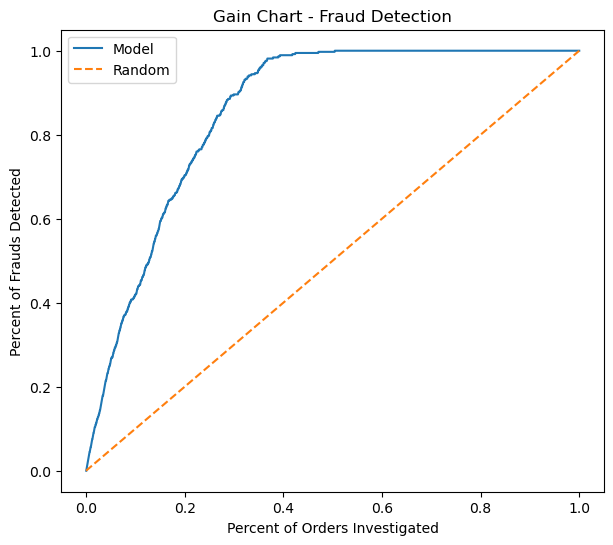

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Probabilidades
proba = best_model.predict_proba(X_test)[:,1]

lift_df = pd.DataFrame({
    "y_true": y_test,
    "prob": proba
})

# Ordenar por risco
lift_df = lift_df.sort_values("prob", ascending=False)

# Percentual acumulado
lift_df["cum_cases"] = np.arange(1, len(lift_df)+1)
lift_df["cum_cases_pct"] = lift_df["cum_cases"] / len(lift_df)

lift_df["cum_frauds"] = lift_df["y_true"].cumsum()
lift_df["total_frauds"] = lift_df["y_true"].sum()

lift_df["cum_frauds_pct"] = lift_df["cum_frauds"] / lift_df["total_frauds"]


plt.figure(figsize=(7,6))

plt.plot(
    lift_df["cum_cases_pct"],
    lift_df["cum_frauds_pct"],
    label="Model",
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Random"
)

plt.xlabel("Percent of Orders Investigated")
plt.ylabel("Percent of Frauds Detected")

plt.title("Gain Chart - Fraud Detection")

plt.legend()

plt.show()

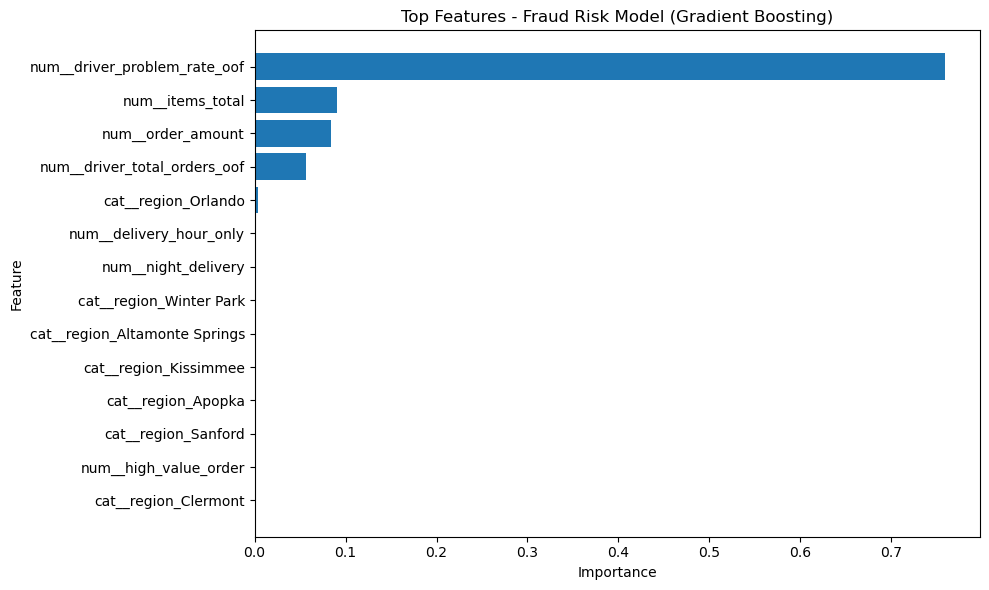

In [67]:
import pandas as pd
import matplotlib.pyplot as plt

# pegar o modelo treinado
model = best_model.named_steps["model"]

# pegar os nomes das variáveis após preprocessamento
feature_names = best_model.named_steps["prep"].get_feature_names_out()

# pegar importâncias
importances = model.feature_importances_

# dataframe ordenado
fi = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

# top 15
fi_top = fi.head(15)

# gráfico
plt.figure(figsize=(10,6))
plt.barh(fi_top["feature"][::-1], fi_top["importance"][::-1])
plt.title("Top Features - Fraud Risk Model (Gradient Boosting)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

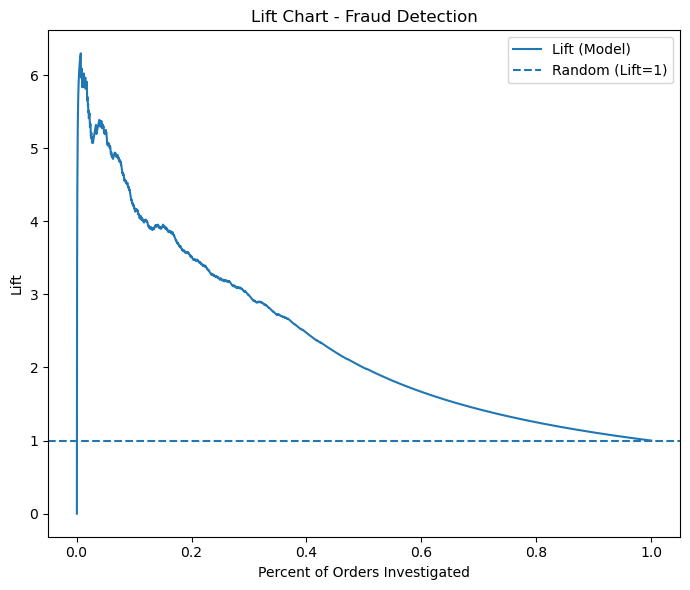

In [69]:
import numpy as np
import matplotlib.pyplot as plt

# lift_df já criado antes (com cum_cases_pct e cum_frauds_pct)
lift_df["lift"] = lift_df["cum_frauds_pct"] / lift_df["cum_cases_pct"]
lift_df.loc[lift_df["cum_cases_pct"] == 0, "lift"] = np.nan  # evitar divisão por zero

plt.figure(figsize=(7,6))
plt.plot(lift_df["cum_cases_pct"], lift_df["lift"], label="Lift (Model)")

plt.axhline(1, linestyle="--", label="Random (Lift=1)")

plt.xlabel("Percent of Orders Investigated")
plt.ylabel("Lift")
plt.title("Lift Chart - Fraud Detection")
plt.legend()
plt.tight_layout()
plt.show()

Base rate: 0.15


,decil,orders,frauds,fraud_rate,lift
0,0,250,157,0.628000,4.186667
1,1,250,107,0.428000,2.853333
2,2,248,72,0.290323,1.935484
3,3,252,35,0.138889,0.925926
4,4,240,3,0.012500,0.083333
5,5,260,1,0.003846,0.025641
6,6,230,0,0.000000,0.000000
7,7,270,0,0.000000,0.000000
8,8,249,0,0.000000,0.000000
9,9,251,0,0.000000,0.000000


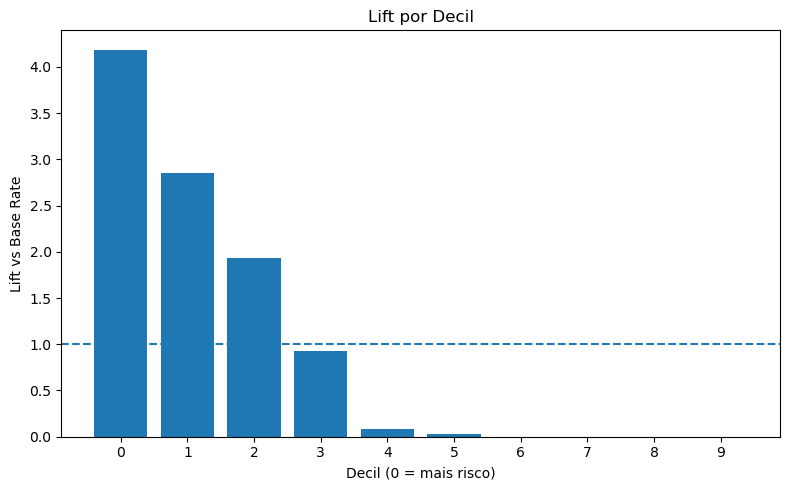

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_lift = lift_df.copy()

# criar decil (10 grupos) com base na probabilidade
df_lift["decil"] = pd.qcut(df_lift["prob"], 10, labels=False, duplicates="drop")  # 0=mais baixo, 9=mais alto
df_lift["decil"] = 9 - df_lift["decil"]  # 9=mais alto risco → decil 0

# taxa base
base_rate = df_lift["y_true"].mean()

lift_by_decil = (
    df_lift.groupby("decil", as_index=False)
    .agg(
        orders=("y_true","count"),
        frauds=("y_true","sum"),
        fraud_rate=("y_true","mean")
    )
)

lift_by_decil["lift"] = lift_by_decil["fraud_rate"] / base_rate

print("Base rate:", round(base_rate,4))
display(lift_by_decil)

# gráfico
plt.figure(figsize=(8,5))
plt.bar(lift_by_decil["decil"].astype(str), lift_by_decil["lift"])
plt.axhline(1, linestyle="--")
plt.xlabel("Decil (0 = mais risco)")
plt.ylabel("Lift vs Base Rate")
plt.title("Lift por Decil")
plt.tight_layout()
plt.show()

In [94]:
for p in [0.1, 0.2, 0.3]:
    fraud_pct = lift_df.loc[lift_df["cum_cases_pct"] <= p, "y_true"].sum() / lift_df["y_true"].sum()
    lift_val = fraud_pct / p
    print(f"Top {int(p*100)}%: captura {fraud_pct:.2%} das fraudes | Lift = {lift_val:.2f}x")

Top 10%: captura 41.87% das fraudes | Lift = 4.19x
Top 20%: captura 70.40% das fraudes | Lift = 3.52x
Top 30%: captura 89.60% das fraudes | Lift = 2.99x


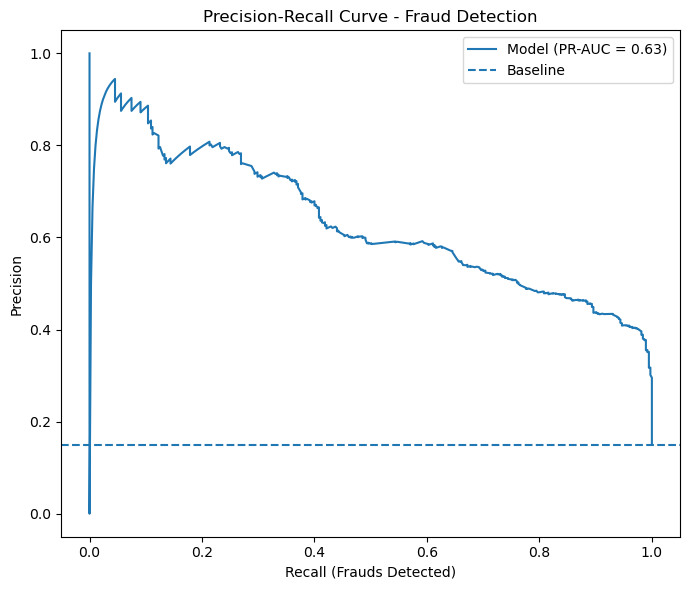

In [73]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
import matplotlib.pyplot as plt

# probabilidades do modelo
proba = best_model.predict_proba(X_test)[:,1]

# calcular curva
precision, recall, thresholds = precision_recall_curve(y_test, proba)

# AUC PR
pr_auc = average_precision_score(y_test, proba)

# gráfico
plt.figure(figsize=(7,6))
plt.plot(recall, precision, label=f"Model (PR-AUC = {pr_auc:.2f})")

# linha base (fraude média)
base_rate = y_test.mean()
plt.axhline(base_rate, linestyle="--", label="Baseline")

plt.xlabel("Recall (Frauds Detected)")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Fraud Detection")
plt.legend()
plt.tight_layout()
plt.show()

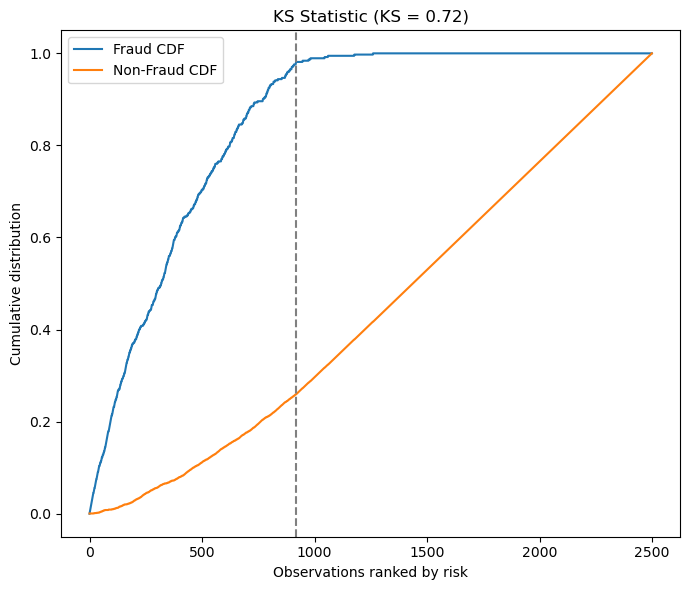

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# probabilidades do modelo
proba = best_model.predict_proba(X_test)[:,1]

# dataframe auxiliar
ks_df = pd.DataFrame({
    "y_true": y_test,
    "prob": proba
})

# ordenar por risco
ks_df = ks_df.sort_values("prob", ascending=False).reset_index(drop=True)

# cumulativos
ks_df["cum_fraud"] = ks_df["y_true"].cumsum() / ks_df["y_true"].sum()
ks_df["cum_nonfraud"] = ((1 - ks_df["y_true"]).cumsum()) / (1 - ks_df["y_true"]).sum()

# KS
ks_df["ks"] = ks_df["cum_fraud"] - ks_df["cum_nonfraud"]
ks_value = ks_df["ks"].max()

# posição do KS
ks_idx = ks_df["ks"].idxmax()

plt.figure(figsize=(7,6))

plt.plot(ks_df["cum_fraud"], label="Fraud CDF")
plt.plot(ks_df["cum_nonfraud"], label="Non-Fraud CDF")

plt.axvline(ks_idx, linestyle="--", color="gray")

plt.title(f"KS Statistic (KS = {ks_value:.2f})")
plt.xlabel("Observations ranked by risk")
plt.ylabel("Cumulative distribution")

plt.legend()
plt.tight_layout()
plt.show()

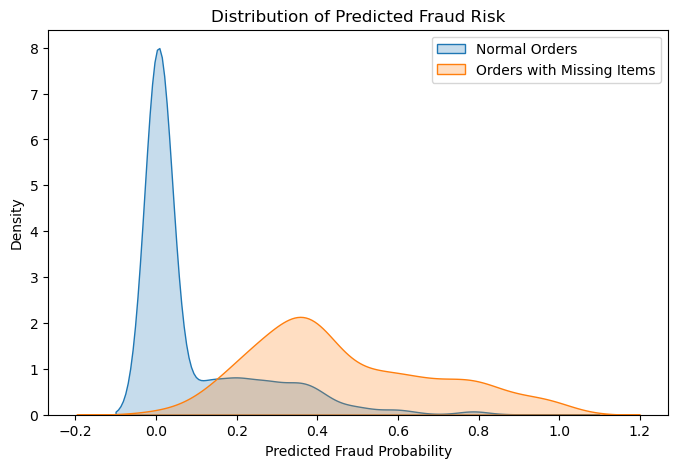

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

# probabilidades do modelo
proba = best_model.predict_proba(X_test)[:,1]

# dataframe auxiliar
proba_df = pd.DataFrame({
    "probability": proba,
    "has_missing": y_test
})

plt.figure(figsize=(8,5))

sns.kdeplot(
    data=proba_df[proba_df["has_missing"]==0],
    x="probability",
    label="Normal Orders",
    fill=True
)

sns.kdeplot(
    data=proba_df[proba_df["has_missing"]==1],
    x="probability",
    label="Orders with Missing Items",
    fill=True
)

plt.xlabel("Predicted Fraud Probability")
plt.title("Distribution of Predicted Fraud Risk")
plt.legend()
plt.show()

In [79]:
# calcular probabilidades
df_orders["risk_probability"] = best_model.predict_proba(X)[:,1]

# criar classificação de risco
def risk_level(p):
    if p > 0.6:
        return "High Risk"
    elif p > 0.3:
        return "Medium Risk"
    else:
        return "Low Risk"

df_orders["risk_level"] = df_orders["risk_probability"].apply(risk_level)

# selecionar colunas para o dashboard
dashboard_df = df_orders[[
    "order_id",
    "risk_probability",
    "risk_level",
    "order_amount",
    "region",
    "driver_id",
    "delivery_hour_only",
    "has_missing"
]]

# salvar csv
dashboard_df.to_csv("orders_scored.csv", index=False)

In [81]:
dashboard_df["risk_probability"].head(5).tolist()

[0.6699355827276673,
 0.6514638486481487,
 0.5326045934569256,
 0.9400682147872844,
 0.4548760603854339]

In [83]:
dashboard_df.to_excel(r"C:\Users\erika\Downloads\orders_scored.xlsx", index=False)

In [85]:
print(dashboard_df["risk_probability"].min(), dashboard_df["risk_probability"].max())

0.0011766693562884633 0.9984313133463687


In [89]:
dashboard_df.loc[:, "risk_probability"] = dashboard_df["risk_probability"].round(4)

In [99]:
len(model.feature_importances_)

14

In [103]:
len(X.columns)

8

In [107]:
print(model.n_features_in_)

14


In [111]:
print(len(X.columns))

8


In [115]:
print(len(X_train.columns))

8


In [121]:
import pandas as pd

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        try:
            if obj.shape[1] == model.n_features_in_:
                print(name, obj.shape)
        except:
            pass